In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

## 1. Chargement

In [2]:
df = pd.read_csv("project_dataset.csv", sep=";")
print(f"Nombre de lignes initiales : {len(df)}")
df.head()

Nombre de lignes initiales : 12070


,Date,Service,Gare de départ,Gare d'arrivée,Durée moyenne du trajet,Nombre de circulations prévues,Nombre de trains annulés,Commentaire annulations,Nombre de trains en retard au départ,Retard moyen des trains en retard au départ,Retard moyen de tous les trains au départ,Commentaire retards au départ,Nombre de trains en retard à l'arrivée,Retard moyen des trains en retard à l'arrivée,Retard moyen de tous les trains à l'arrivée,Commentaire retards à l'arrivée,Nombre trains en retard > 15min,Retard moyen trains en retard > 15 (si liaison concurrencée par vol),Nombre trains en retard > 30min,Nombre trains en retard > 60min,Prct retard pour causes externes,Prct retard pour cause infrastructure,Prct retard pour cause gestion trafic,Prct retard pour cause matériel roulant,Prct retard pour cause gestion en gare et réutilisation de matériel,"Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, correspondances)"
0,2018-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141.0,870,5.0,NaN,289.0,11.24780854,3.693179191,NaN,147.0,28.43673469,6.511117534,NaN,110.0,6.51,44.0,8.0,36.13445378,31.09243697,10.92436975,15.96638655,"5,04",0.840336134
1,2018-01,National,LE MANS,PARIS MONTPARNASSE,56.0,406.0,1.0,NaN,213.0,8.479968701,4.567119342,NaN,105.0,18.049,5.363539095,"Ce mois-ci, l'OD a été touchée par les inciden...",32.0,5.363539095,9.0,4.0,20.0,35.0,16.66666667,16.66666667,8.333333333,3.333333333
2,2018-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166.0,226.0,0.0,NaN,21.0,6.23968254,0.286283186,NaN,19.0,24.73684211,2.938053097,NaN,11.0,2.938053097,6.0,1.0,22.22222222,27.77777778,16.66666667,16.66666667,5.555555556,11.11111111
3,2018-01,National,PARIS MONTPARNASSE,NANTES,216.21,508.0,3.0,NaN,71.0,7.235211268,0.98,NaN,58.0,33.72643678,5.292211221,NaN,39.0,5.292211221,18.0,NaN,33.33333333,22.22222222,16.66666667,20.37037037,5.555555556,1.851851852
4,2018-01,National,POITIERS,PARIS MONTPARNASSE,94.0,472.0,4.0,NaN,224.0,6.784672619,3.229700855,NaN,89.0,14.59269663,4.882371795,NaN,42.0,4.882371795,10.0,0.0,15.78947368,45.61403509,NaN,15.78947368,1.754385965,1.754385965


## 2. Filtrage des lignes parasites

In [3]:
# On garde uniquement les lignes dont la date commence par un chiffre
df = df[df['Date'].astype(str).str.match(r'^\d', na=False)].copy()
print(f"Lignes après filtrage des commentaires : {len(df)}")

Lignes après filtrage des commentaires : 12010


## 3. Standardisation des colonnes texte

In [4]:
text_cols = ["Gare de départ", "Gare d'arrivée", "Service"]
for col in text_cols:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
            .str.upper()
            .str.replace(r'\s+', ' ', regex=True)
        )

## 4. Suppression des doublons

In [5]:
initial_count = len(df)
df = df.drop_duplicates()
print(f"Doublons supprimés : {initial_count - len(df)}")
print(f"Lignes restantes   : {len(df)}")

Doublons supprimés : 214
Lignes restantes   : 11796


## 5. Conversion numérique

In [6]:
numeric_cols = [
    "Durée moyenne du trajet", "Nombre de circulations prévues", "Nombre de trains annulés",
    "Nombre de trains en retard au départ", "Retard moyen des trains en retard au départ",
    "Retard moyen de tous les trains au départ", "Nombre de trains en retard à l'arrivée",
    "Retard moyen des trains en retard à l'arrivée", "Retard moyen de tous les trains à l'arrivée",
    "Nombre trains en retard > 15min", "Retard moyen trains en retard > 15 (si liaison concurrencée par vol)",
    "Nombre trains en retard > 30min", "Nombre trains en retard > 60min",
    "Prct retard pour causes externes", "Prct retard pour cause infrastructure",
    "Prct retard pour cause gestion trafic", "Prct retard pour cause matériel roulant",
    "Prct retard pour cause gestion en gare et réutilisation de matériel",
    "Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, correspondances)"
]

numeric_cols = [c for c in numeric_cols if c in df.columns]

for col in numeric_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '.', regex=False)
        .str.strip()
        .replace({'-': np.nan, '': np.nan, 'nan': np.nan, 'None': np.nan})
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Conversion numérique terminée.")
nan_counts = df[numeric_cols].isnull().sum()
print(f"NaN dans les colonnes numériques :\n{nan_counts[nan_counts > 0]}")

Conversion numérique terminée.
NaN dans les colonnes numériques :
Durée moyenne du trajet                                                                        301
Nombre de circulations prévues                                                                 236
Nombre de trains annulés                                                                       236
Nombre de trains en retard au départ                                                           235
Retard moyen des trains en retard au départ                                                    293
Retard moyen de tous les trains au départ                                                      291
Nombre de trains en retard à l'arrivée                                                         235
Retard moyen des trains en retard à l'arrivée                                                  299
Retard moyen de tous les trains à l'arrivée                                                    292
Nombre trains en retard > 15min            

## 6. Conversion de la date

In [7]:
df["Date"] = pd.to_datetime(df["Date"], format="mixed", dayfirst=False, errors="coerce")

nb_dates_invalides = df["Date"].isnull().sum()
if nb_dates_invalides > 0:
    print(f"{nb_dates_invalides} lignes avec date invalide supprimées.")
df = df.dropna(subset=['Date'])

df["Année"] = df["Date"].dt.year.astype(int)
df["Mois"]  = df["Date"].dt.month.astype(int)

print(f"Plage temporelle : {df['Date'].min().date()} → {df['Date'].max().date()}")

Plage temporelle : 2018-01-01 → 2025-12-01


## 7. Typage final

In [8]:
df = df.astype({col: 'string' for col in df.select_dtypes(include='object').columns})
print(df.dtypes)

Date                                                                                           datetime64[us]
Service                                                                                                string
Gare de départ                                                                                         string
Gare d'arrivée                                                                                         string
Durée moyenne du trajet                                                                               float64
Nombre de circulations prévues                                                                        float64
Nombre de trains annulés                                                                              float64
Commentaire annulations                                                                                string
Nombre de trains en retard au départ                                                                  float64
Retard moy

/tmp/ipykernel_149798/2598984038.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df = df.astype({col: 'string' for col in df.select_dtypes(include='object').columns})


## 8. Gestion des valeurs manquantes

In [9]:
# Colonnes numériques : on remplace par 0
df[numeric_cols] = df[numeric_cols].fillna(0)

comment_cols = [
    "Commentaire annulations",
    "Commentaire retards au départ",
    "Commentaire retards à l'arrivée"
]
for col in comment_cols:
    if col in df.columns:
        df[col] = df[col].fillna("Non communiqué")

# Colonnes catégorielles
categorical_cols = ["Service", "Gare de départ", "Gare d'arrivée"]
_invalid_values = ["", "nan", "none", "NAN", "NONE", "NAT", "0", "INCONNU", "<NA>"]

for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].str.strip()
        df[col] = df[col].replace(_invalid_values, pd.NA)
        df[col] = df[col].fillna("Inconnu")

# Suppression des lignes sans Service
initial_len = len(df)
df = df[df["Service"] != "Inconnu"]
print(f"Lignes supprimées car 'Service' manquant : {initial_len - len(df)}")

# Suppression des lignes sans gare
initial_len = len(df)
df = df[(df["Gare de départ"] != "Inconnu") & (df["Gare d'arrivée"] != "Inconnu")]
print(f"Lignes supprimées car gare manquante : {initial_len - len(df)}")

print(f"\nValeurs manquantes restantes : {df.isnull().sum().sum()}")

Lignes supprimées car 'Service' manquant : 232
Lignes supprimées car gare manquante : 130

Valeurs manquantes restantes : 0


## 9. NOUVEAU — Corrections qualité

### 9.1 Uniformisation des commentaires

In [10]:
comment_replacements = ["-", "NC", "<NA>", "nan", ""]

for col in comment_cols:
    if col in df.columns:
        df[col] = df[col].fillna("Non communiqué")
        df[col] = df[col].replace(comment_replacements, "Non communiqué")
        df[col] = df[col].apply(
            lambda x: "Non communiqué" if (pd.isna(x) or str(x).strip() in ["", "-", "NC", "nan", "<NA>"]) else x
        )
        # Cast final pour s'assurer qu'il n'y a plus aucun NA
        df[col] = df[col].astype(str).replace("nan", "Non communiqué")

for col in comment_cols:
    print(f"\n{col}:")
    print(df[col].value_counts().head(3))


Commentaire annulations:
Commentaire annulations
Non communiqué    11434
Name: count, dtype: int64

Commentaire retards au départ:
Commentaire retards au départ
Non communiqué    11434
Name: count, dtype: int64

Commentaire retards à l'arrivée:
Commentaire retards à l'arrivée
Non communiqué                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

### 9.2 Valeurs négatives impossibles = 0

In [11]:
# Les retards moyens et les comptages ne peuvent pas être négatifs
# Les valeurs négatives sont des erreurs de saisie ou d'encodage = remplacées par 0
cols_non_negative = [
    "Retard moyen de tous les trains au départ",
    "Retard moyen de tous les trains à l'arrivée",
    "Retard moyen des trains en retard à l'arrivée",
    "Retard moyen trains en retard > 15 (si liaison concurrencée par vol)",
    "Nombre trains en retard > 30min",
]

for col in cols_non_negative:
    if col in df.columns:
        n_neg = (df[col] < 0).sum()
        if n_neg > 0:
            print(f"  {col}: {n_neg} valeurs négatives → remplacées par 0")
            df[col] = df[col].clip(lower=0)

  Retard moyen de tous les trains au départ: 155 valeurs négatives → remplacées par 0
  Retard moyen de tous les trains à l'arrivée: 110 valeurs négatives → remplacées par 0
  Retard moyen des trains en retard à l'arrivée: 2 valeurs négatives → remplacées par 0
  Retard moyen trains en retard > 15 (si liaison concurrencée par vol): 7 valeurs négatives → remplacées par 0
  Nombre trains en retard > 30min: 42 valeurs négatives → remplacées par 0


### 9.3 Durée de trajet = 0 : NaN puis suppression

In [12]:
# Une durée de trajet à 0 est physiquement impossible → on supprime ces lignes
initial_len = len(df)
df = df[df["Durée moyenne du trajet"] > 0]
print(f"Lignes supprimées car durée de trajet = 0 : {initial_len - len(df)}")

Lignes supprimées car durée de trajet = 0 : 358


### 9.4 Flag causes de retard inconnues

In [13]:
# Quand toutes les colonnes Prct sont à 0, on ne sait pas si c'est 'pas de retard'
# ou 'données non renseignées'. On crée un flag pour distinguer.
pct_cols = [c for c in df.columns if c.startswith('Prct')]

df["causes_connues"] = df[pct_cols].sum(axis=1) > 0

print(f"Lignes avec causes connues   : {df['causes_connues'].sum()}")
print(f"Lignes avec causes inconnues : {(~df['causes_connues']).sum()}")

Lignes avec causes connues   : 10883
Lignes avec causes inconnues : 193


## 10. Export

In [14]:
# Suppression des sauts de ligne dans les commentaires (sinon CSV cassé)
comment_cols_export = [
    "Commentaire annulations",
    "Commentaire retards au départ",
    "Commentaire retards à l'arrivée"
]
for col in comment_cols_export:
    if col in df.columns:
        df[col] = df[col].fillna("Non communiqué")
        df[col] = df[col].astype(str).replace("<NA>", "Non communiqué")
        df[col] = df[col].str.replace(r'[\n\r]+', ' ', regex=True).str.strip()

# Conversion de Date en string pour éviter la perte du format à l'export
df["Date"] = df["Date"].dt.strftime("%Y-%m-%d")

df = df.drop_duplicates()
df = df.drop_duplicates(subset=["Date", "Gare de départ", "Gare d'arrivée"])

output_file = "cleaned_dataset.csv"
df.to_csv(output_file, index=False, sep=",", encoding="utf-8", quoting=1)

print(f"Dataset nettoyé exporté : {output_file}")
print(f"Lignes finales : {len(df)}")
df.info()

# Vérification colonnes ou il y a du texte dans le CSV exporté
df_check = pd.read_csv("cleaned_dataset.csv", sep=",")
has_problem = False
for col in comment_cols_export:
    if col in df_check.columns:
        null_count = df_check[col].isnull().sum()
        if null_count > 0:
            print(f"KO: {col} contient {null_count} valeurs nulles")
            has_problem = True
if not has_problem:
    print("OK")

Dataset nettoyé exporté : cleaned_dataset.csv
Lignes finales : 11020
<class 'pandas.DataFrame'>
Index: 11020 entries, 0 to 12002
Data columns (total 29 columns):
 #   Column                                                                                       Non-Null Count  Dtype  
---  ------                                                                                       --------------  -----  
 0   Date                                                                                         11020 non-null  str    
 1   Service                                                                                      11020 non-null  string 
 2   Gare de départ                                                                               11020 non-null  string 
 3   Gare d'arrivée                                                                               11020 non-null  string 
 4   Durée moyenne du trajet                                                                      11020 no

# Visualisation et anlayse des données cleaned 

Ce notebook contient le code pour visualiser les tendances, les distributions et les corrélations sur les retards de trains.

In [15]:
df = pd.read_csv("cleaned_dataset.csv", sep=',')
print(df.head())

         Date   Service      Gare de départ      Gare d'arrivée  \
0  2018-01-01  NATIONAL    BORDEAUX ST JEAN  PARIS MONTPARNASSE   
1  2018-01-01  NATIONAL             LE MANS  PARIS MONTPARNASSE   
2  2018-01-01  NATIONAL  PARIS MONTPARNASSE   LA ROCHELLE VILLE   
3  2018-01-01  NATIONAL  PARIS MONTPARNASSE              NANTES   
4  2018-01-01  NATIONAL            POITIERS  PARIS MONTPARNASSE   

   Durée moyenne du trajet  Nombre de circulations prévues  \
0                   141.00                           870.0   
1                    56.00                           406.0   
2                   166.00                           226.0   
3                   216.21                           508.0   
4                    94.00                           472.0   

   Nombre de trains annulés Commentaire annulations  \
0                       5.0          Non communiqué   
1                       1.0          Non communiqué   
2                       0.0          Non communiqué   
3   

In [16]:
print("Noms des colonnes du dataset :")
print(df.columns.tolist())

Noms des colonnes du dataset :
['Date', 'Service', 'Gare de départ', "Gare d'arrivée", 'Durée moyenne du trajet', 'Nombre de circulations prévues', 'Nombre de trains annulés', 'Commentaire annulations', 'Nombre de trains en retard au départ', 'Retard moyen des trains en retard au départ', 'Retard moyen de tous les trains au départ', 'Commentaire retards au départ', "Nombre de trains en retard à l'arrivée", "Retard moyen des trains en retard à l'arrivée", "Retard moyen de tous les trains à l'arrivée", "Commentaire retards à l'arrivée", 'Nombre trains en retard > 15min', 'Retard moyen trains en retard > 15 (si liaison concurrencée par vol)', 'Nombre trains en retard > 30min', 'Nombre trains en retard > 60min', 'Prct retard pour causes externes', 'Prct retard pour cause infrastructure', 'Prct retard pour cause gestion trafic', 'Prct retard pour cause matériel roulant', 'Prct retard pour cause gestion en gare et réutilisation de matériel', 'Prct retard pour cause prise en compte voyageurs 

In [17]:
colonne_retard = "Retard moyen de tous les trains à l'arrivée"
print(df[colonne_retard].describe())

count    11020.000000
mean         6.068020
std          4.264190
min          0.000000
25%          3.287420
50%          5.269892
75%          8.010822
max         92.000000
Name: Retard moyen de tous les trains à l'arrivée, dtype: float64


Nombre de trains :
en_retard
1    10363
0      657
Name: count, dtype: int64


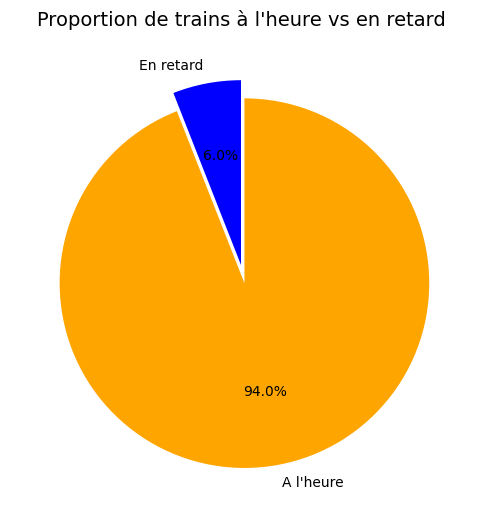

Pourcentage de trains en retard : 94.04%
Pourcentage de trains à l'heure : 5.96%


In [ ]:

colonne_retard = "Retard moyen de tous les trains à l'arrivée"
df[colonne_retard] = df[colonne_retard].clip(lower=0)  

df["en_retard"] = (df[colonne_retard] > 1).astype(int)

# Compte le nombre de trains à l'heure et en retard
retard_counts = df["en_retard"].value_counts()
print("Nombre de trains :")
print(retard_counts)

# Trace le pie chart avec les bons titres
labels = ["En retard", "A l'heure"]
sizes = [retard_counts.get(0, 0), retard_counts.get(1, 0)]
colors = ["blue", "orange"]

plt.figure(figsize=(8, 6))
plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    explode=(0, 0.1)
)
plt.title("Proportion de trains à l'heure vs en retard", fontsize=14)
plt.show()

# Affiche les pourcentages
total_trains = len(df)
pourcentage_retard = (retard_counts.get(1, 0) / total_trains) * 100
pourcentage_a_lheure = (retard_counts.get(0, 0) / total_trains) * 100

print(f"Pourcentage de trains en retard : {pourcentage_retard:.2f}%")
print(f"Pourcentage de trains à l'heure : {pourcentage_a_lheure:.2f}%")

In [19]:
nombre_total_trains = len(df)
print(f"Nombre de circulations prévues : {nombre_total_trains}")

Nombre de circulations prévues : 11020


In [20]:
colonne_service = "Service"
print(f"\nValeurs uniques dans '{colonne_service}' :")
print(df[colonne_service].unique())


Valeurs uniques dans 'Service' :
<StringArray>
['NATIONAL', 'INTERNATIONAL']
Length: 2, dtype: str


Nombre total de trains par type de service :
Service
NATIONAL         9682
INTERNATIONAL    1338
Name: count, dtype: int64

Nombre de trains en retard par type de service (seuil = 10 min) :
Service
NATIONAL         1196
INTERNATIONAL     379
Name: count, dtype: int64


/tmp/ipykernel_149798/2143251834.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


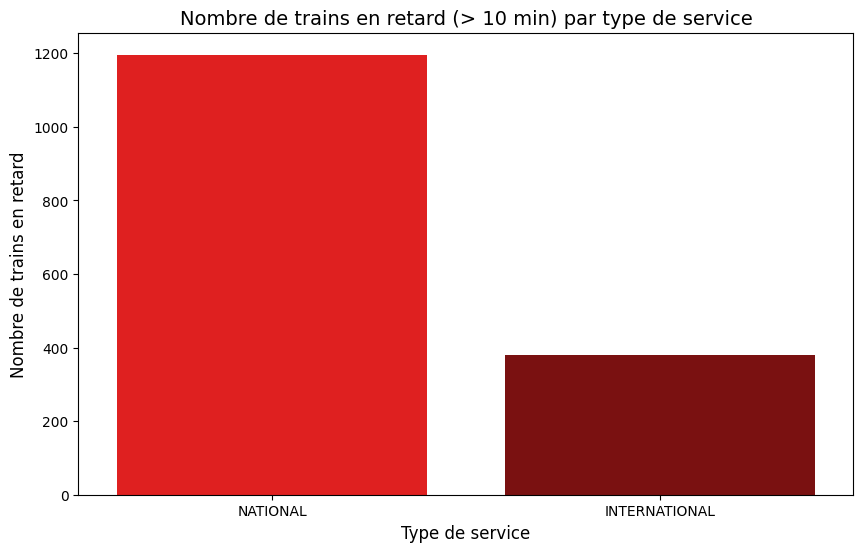

In [ ]:
# Vérifie le total par type de service
colonne_service = "Service"
total_par_service = df[colonne_service].value_counts()
print("Nombre total de trains par type de service :")
print(total_par_service)

colonne_retard = "Retard moyen de tous les trains à l'arrivée"
seuil_retard = 10
df["en_retard"] = (df[colonne_retard] > seuil_retard).astype(int)

# Compte les trains en retard par type de service
nombre_retards_par_service = df[df["en_retard"] == 1][colonne_service].value_counts()
print("\nNombre de trains en retard par type de service (seuil = 10 min) :")
print(nombre_retards_par_service)

# Visualisation
plt.figure(figsize=(10, 6))
sns.barplot(
    x=nombre_retards_par_service.index,
    y=nombre_retards_par_service.values,
    palette=["red", "darkred"]
)
plt.title(f"Nombre de trains en retard (> {seuil_retard} min) par type de service", fontsize=14)
plt.xlabel("Type de service", fontsize=12)
plt.ylabel("Nombre de trains en retard", fontsize=12)
plt.show()

Colonnes disponibles :
['Date', 'Service', 'Gare de départ', "Gare d'arrivée", 'Durée moyenne du trajet', 'Nombre de circulations prévues', 'Nombre de trains annulés', 'Commentaire annulations', 'Nombre de trains en retard au départ', 'Retard moyen des trains en retard au départ', 'Retard moyen de tous les trains au départ', 'Commentaire retards au départ', "Nombre de trains en retard à l'arrivée", "Retard moyen des trains en retard à l'arrivée", "Retard moyen de tous les trains à l'arrivée", "Commentaire retards à l'arrivée", 'Nombre trains en retard > 15min', 'Retard moyen trains en retard > 15 (si liaison concurrencée par vol)', 'Nombre trains en retard > 30min', 'Nombre trains en retard > 60min', 'Prct retard pour causes externes', 'Prct retard pour cause infrastructure', 'Prct retard pour cause gestion trafic', 'Prct retard pour cause matériel roulant', 'Prct retard pour cause gestion en gare et réutilisation de matériel', 'Prct retard pour cause prise en compte voyageurs (affluen

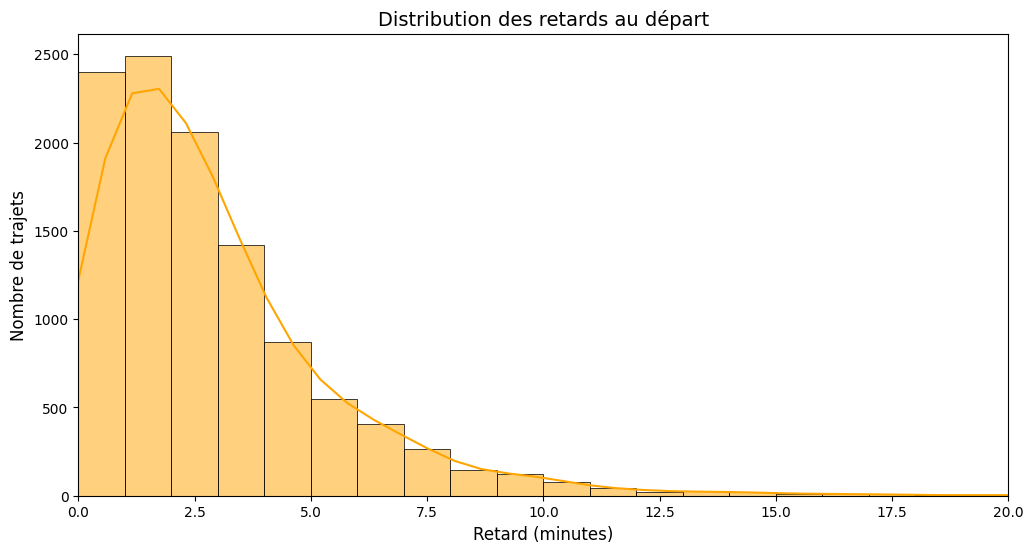

In [ ]:
# Vérifie les noms des colonnes
print("Colonnes disponibles :")
print(df.columns.tolist())


colonne_retard = "Retard moyen de tous les trains au départ"
colonne_service = "Service"

# Affiche les premières lignes pour vérifier
print("\n5 premières lignes :")
print(df[[colonne_retard, colonne_service]].head(5))

df[colonne_service] = df[colonne_service].fillna("Inconnu")
print(f"\nNaN restants dans '{colonne_service}' : {df[colonne_service].isna().sum()}")

df["en_retard"] = (df[colonne_retard] > 3).astype(int)
print("\nNombre de trains en retard (seuil 3 min) :")
print(df["en_retard"].value_counts())

# Vérifie les statistiques des retards
print("\nStatistiques des retards :")
print(df[colonne_retard].describe())

plt.figure(figsize=(12, 6))
sns.histplot(data=df, x=colonne_retard, bins=range(0, 60, 1), kde=True, color='orange')
plt.xlim(0, 20)
plt.title("Distribution des retards au départ", fontsize=14)
plt.xlabel("Retard (minutes)", fontsize=12)
plt.ylabel("Nombre de trajets", fontsize=12)
plt.show()

Colonnes disponibles :
['Date', 'Service', 'Gare de départ', "Gare d'arrivée", 'Durée moyenne du trajet', 'Nombre de circulations prévues', 'Nombre de trains annulés', 'Commentaire annulations', 'Nombre de trains en retard au départ', 'Retard moyen des trains en retard au départ', 'Retard moyen de tous les trains au départ', 'Commentaire retards au départ', "Nombre de trains en retard à l'arrivée", "Retard moyen des trains en retard à l'arrivée", "Retard moyen de tous les trains à l'arrivée", "Commentaire retards à l'arrivée", 'Nombre trains en retard > 15min', 'Retard moyen trains en retard > 15 (si liaison concurrencée par vol)', 'Nombre trains en retard > 30min', 'Nombre trains en retard > 60min', 'Prct retard pour causes externes', 'Prct retard pour cause infrastructure', 'Prct retard pour cause gestion trafic', 'Prct retard pour cause matériel roulant', 'Prct retard pour cause gestion en gare et réutilisation de matériel', 'Prct retard pour cause prise en compte voyageurs (affluen

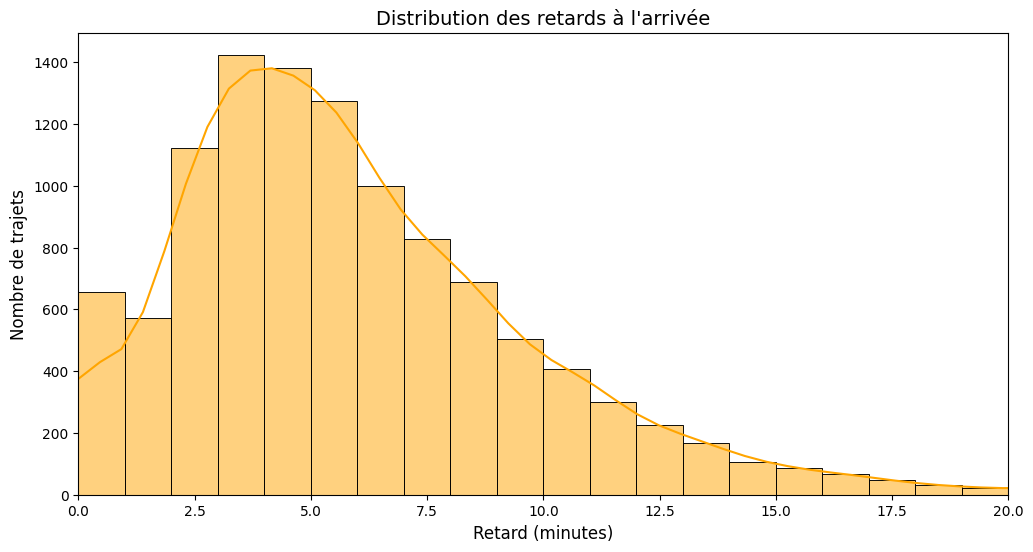

In [ ]:
# Vérifie les noms des colonnes
print("Colonnes disponibles :")
print(df.columns.tolist())

colonne_retard = "Retard moyen de tous les trains à l'arrivée"
colonne_service = "Service" 

# Affiche les premières lignes pour vérifier
print("\n5 premières lignes :")
print(df[[colonne_retard, colonne_service]].head(5))

df[colonne_service] = df[colonne_service].fillna("Inconnu")
print(f"\nNaN restants dans '{colonne_service}' : {df[colonne_service].isna().sum()}")

df["en_retard"] = (df[colonne_retard] > 3).astype(int)
print("\nNombre de trains en retard (seuil 3 min) :")
print(df["en_retard"].value_counts())

# Vérifie les statistiques des retards
print("\nStatistiques des retards :")
print(df[colonne_retard].describe())

plt.figure(figsize=(12, 6))
sns.histplot(data=df, x=colonne_retard, bins=range(0, 60, 1), kde=True, color='orange')
plt.xlim(0, 20)
plt.title("Distribution des retards à l'arrivée", fontsize=14)
plt.xlabel("Retard (minutes)", fontsize=12)
plt.ylabel("Nombre de trajets", fontsize=12)
plt.show()

Statistiques des retards au départ (en minutes) :
count    11020.000000
mean        12.087210
std         11.937160
min          0.000000
25%          5.941213
50%         10.224181
75%         15.604509
max        316.188000
Name: Retard moyen des trains en retard au départ, dtype: float64
/nStatistiques des retards à l'arrivée (en minutes) :
count    11020.000000
mean        34.525975
std         16.259427
min          0.000000
25%         25.086630
50%         33.187992
75%         42.288125
max        299.600000
Name: Retard moyen des trains en retard à l'arrivée, dtype: float64

Top 10 des gares avec le plus de retards moyens au départ :
Gare de départ
GRENOBLE                      30.868276
QUIMPER                       18.700146
ANNECY                        18.069528
SAINT ETIENNE CHATEAUCREUX    17.461215
TOULOUSE MATABIAU             16.733037
BREST                         16.427267
TOURCOING                     15.971602
ITALIE                        15.912188
PARIS LYON    

/tmp/ipykernel_149798/1242234745.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=retards_depart_par_gare.index, y=retards_depart_par_gare.values, palette="viridis")


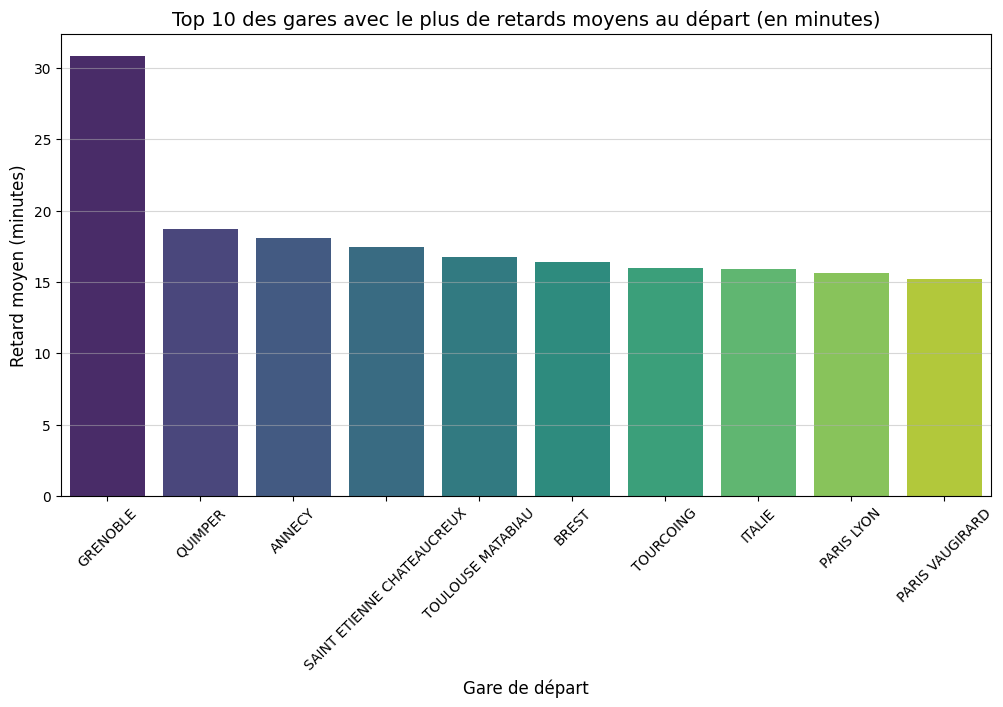


Top 10 des gares avec le plus de retards moyens à l'arrivée :
Gare d'arrivée
TOULOUSE MATABIAU      48.882751
NICE VILLE             47.904574
PERPIGNAN              47.427914
AIX EN PROVENCE TGV    44.129262
TOULON                 43.751272
QUIMPER                43.308189
TOURCOING              43.305822
BREST                  42.039922
BARCELONA              41.708126
ITALIE                 40.832394
Name: Retard moyen des trains en retard à l'arrivée, dtype: float64


/tmp/ipykernel_149798/1242234745.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=retards_arrivee_par_gare.index, y=retards_arrivee_par_gare.values, palette="magma")


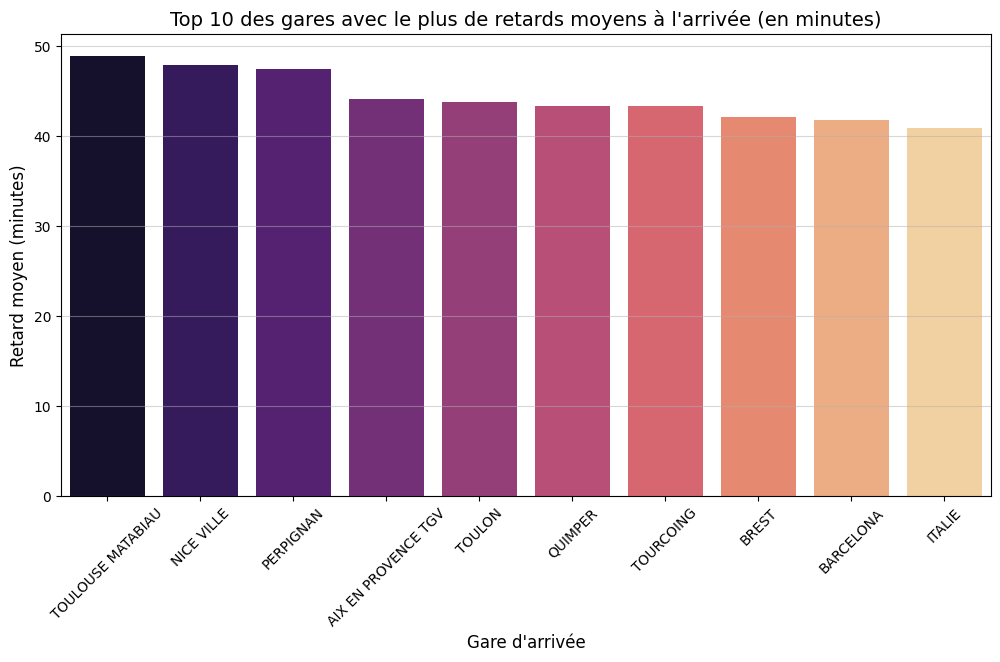

In [ ]:

colonne_retard_depart = "Retard moyen des trains en retard au départ"
colonne_retard_arrivee = "Retard moyen des trains en retard à l'arrivée"
colonne_gare_depart = "Gare de départ"
colonne_gare_arrivee = "Gare d'arrivée"

# Affiche les statistiques pour vérifier
print("Statistiques des retards au départ (en minutes) :")
print(df[colonne_retard_depart].describe())
print("/nStatistiques des retards à l'arrivée (en minutes) :")
print(df[colonne_retard_arrivee].describe())

# Retards moyens par gare de départ
retards_depart_par_gare = df.groupby(colonne_gare_depart)[colonne_retard_depart].mean().sort_values(ascending=False).head(10)
print("\nTop 10 des gares avec le plus de retards moyens au départ :")
print(retards_depart_par_gare)

# Visualisation des retards moyens au départ
plt.figure(figsize=(12, 6))
sns.barplot(x=retards_depart_par_gare.index, y=retards_depart_par_gare.values, palette="viridis")
plt.title("Top 10 des gares avec le plus de retards moyens au départ (en minutes)", fontsize=14)
plt.xlabel("Gare de départ", fontsize=12)
plt.ylabel("Retard moyen (minutes)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.5)
plt.show()

# Retards moyens par gare d'arrivée
retards_arrivee_par_gare = df.groupby(colonne_gare_arrivee)[colonne_retard_arrivee].mean().sort_values(ascending=False).head(10)
df[colonne_retard_arrivee] = df [colonne_retard_arrivee] / 60
print("\nTop 10 des gares avec le plus de retards moyens à l'arrivée :")
print(retards_arrivee_par_gare)

# Visualisation des retards moyens à l'arrivée
plt.figure(figsize=(12, 6))
sns.barplot(x=retards_arrivee_par_gare.index, y=retards_arrivee_par_gare.values, palette="magma")
plt.title("Top 10 des gares avec le plus de retards moyens à l'arrivée (en minutes)", fontsize=14)
plt.xlabel("Gare d'arrivée", fontsize=12)
plt.ylabel("Retard moyen (minutes)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.5)
plt.show()
